In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df_full = pd.read_csv('../data/raw/student_mental_health_burnout_1M.csv')

# Ambil sample per kelas secara merata
n_per_class = 15000  # 15K per kelas → total 45K

df = df_full.groupby('risk_level', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), n_per_class), random_state=42)
).reset_index(drop=True)

# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Full dataset : {df_full.shape[0]:,} rows")
print(f"Sample       : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nSample distribution:")
counts = df['risk_level'].value_counts()
pcts   = df['risk_level'].value_counts(normalize=True) * 100
for lvl in ['Low', 'Medium', 'High']:
    print(f"  {lvl:<10}: {counts[lvl]:>6,}  ({pcts[lvl]:.1f}%)")
df.head()

Full dataset : 1,000,000 rows
Sample       : 45,000 rows × 20 columns

Sample distribution:
  Low       : 15,000  (33.3%)
  Medium    : 15,000  (33.3%)
  High      : 15,000  (33.3%)


C:\Users\zahra\AppData\Local\Temp\ipykernel_11624\784308494.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df_full.groupby('risk_level', group_keys=False).apply(


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,20,Female,4,2.730820,4.850862,60.300038,5.243260,4.107601,1.685632,6.730780,3.792768,4.803484,7.168959,7.153069,7.875235,5.087090,3.080292,6.164726,Medium,2.810641
1,21,Male,4,6.006462,6.989138,72.498312,7.912069,5.178125,4.469066,4.443861,0.970499,4.663864,5.116087,5.547409,4.790890,8.260161,7.554783,3.941015,High,4.964135
2,19,Female,2,8.647586,7.997322,69.182170,4.804022,5.524058,2.782752,5.273105,5.069558,7.784344,1.466554,1.073356,4.444326,6.325128,3.085731,5.586348,Medium,1.629859
3,28,Male,1,5.575063,6.949871,69.122998,6.487279,4.156164,3.775590,3.938624,6.225925,5.923078,9.966368,9.536901,3.938840,8.636600,6.290635,5.025562,High,3.847302
4,23,Female,3,7.558773,7.945329,68.566738,7.083566,4.843014,4.744509,3.307270,1.775822,2.853231,6.512696,4.568547,7.095896,4.570003,5.031301,4.290316,Medium,5.552106


In [32]:
print(f"Data Types: \n{df.dtypes}")
print(f"\nMissing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")

Data Types: 
age                       int64
gender                   object
academic_year             int64
study_hours_per_day     float64
exam_pressure           float64
academic_performance    float64
stress_level            float64
anxiety_score           float64
depression_score        float64
sleep_hours             float64
physical_activity       float64
social_support          float64
screen_time             float64
internet_usage          float64
financial_stress        float64
family_expectation      float64
burnout_score           float64
mental_health_index     float64
risk_level               object
dropout_risk            float64
dtype: object

Missing values : 0
Duplicate rows : 0


In [33]:
df.describe().round(3)

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000
mean,23.002,2.499,5.784,6.782,71.410,5.736,4.181,2.311,5.865,2.820,4.464,5.012,5.027,5.681,6.488,3.941,5.758,2.614
std,3.740,1.115,2.072,1.627,5.667,1.998,1.760,1.577,1.513,1.455,2.005,1.962,2.158,2.023,1.954,2.454,1.640,1.855
min,17.000,1.000,0.000,1.000,48.083,0.000,0.000,0.000,3.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.310,0.000
25%,20.000,2.000,4.383,5.678,67.609,4.360,2.958,1.028,4.778,1.791,3.064,3.649,3.487,4.316,5.163,1.900,4.500,1.012
50%,23.000,2.000,5.805,6.830,71.417,5.873,4.266,2.295,5.824,2.802,4.442,4.993,4.984,5.705,6.530,3.902,5.655,2.579
75%,26.000,3.000,7.195,7.944,75.226,7.233,5.462,3.468,6.896,3.818,5.825,6.349,6.493,7.084,7.910,6.230,6.948,4.017
max,29.000,4.000,13.638,10.000,95.957,10.000,10.000,8.531,10.000,7.000,10.000,12.000,13.740,10.000,10.000,10.000,10.000,9.326


  Low       : 15,000  (33.3%)
  Medium    : 15,000  (33.3%)
  High      : 15,000  (33.3%)


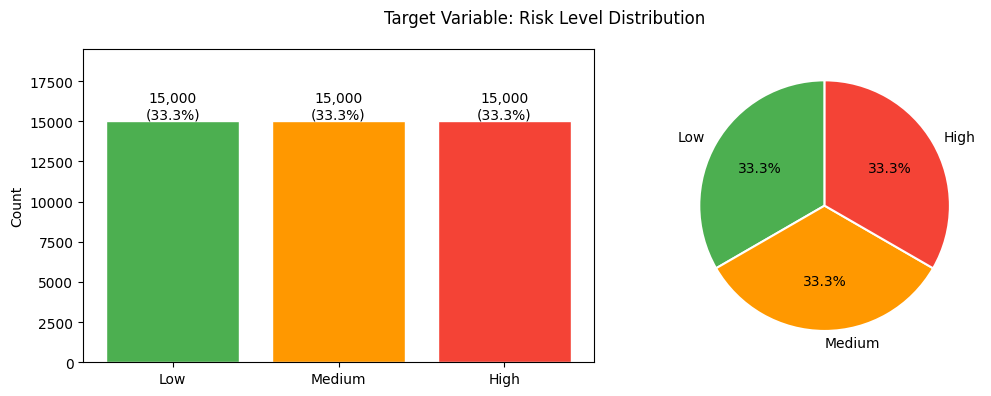

In [34]:
ORDER   = ['Low', 'Medium', 'High']
PALETTE = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}

counts = df['risk_level'].value_counts().reindex(ORDER)
pcts   = df['risk_level'].value_counts(normalize=True).reindex(ORDER) * 100

for lvl, cnt, pct in zip(ORDER, counts, pcts):
    print(f"  {lvl:<10}: {cnt:>6,}  ({pct:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Target Variable: Risk Level Distribution")

axes[0].bar(ORDER, counts, color=[PALETTE[l] for l in ORDER], edgecolor='white')
for i, (cnt, pct) in enumerate(zip(counts, pcts)):
    axes[0].text(i, cnt + 200, f"{cnt:,}\n({pct:.1f}%)", ha='center')
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, max(counts) * 1.3)

axes[1].pie(counts, labels=ORDER, autopct='%1.1f%%',
            colors=[PALETTE[l] for l in ORDER],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))

plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', bbox_inches='tight')
plt.show()

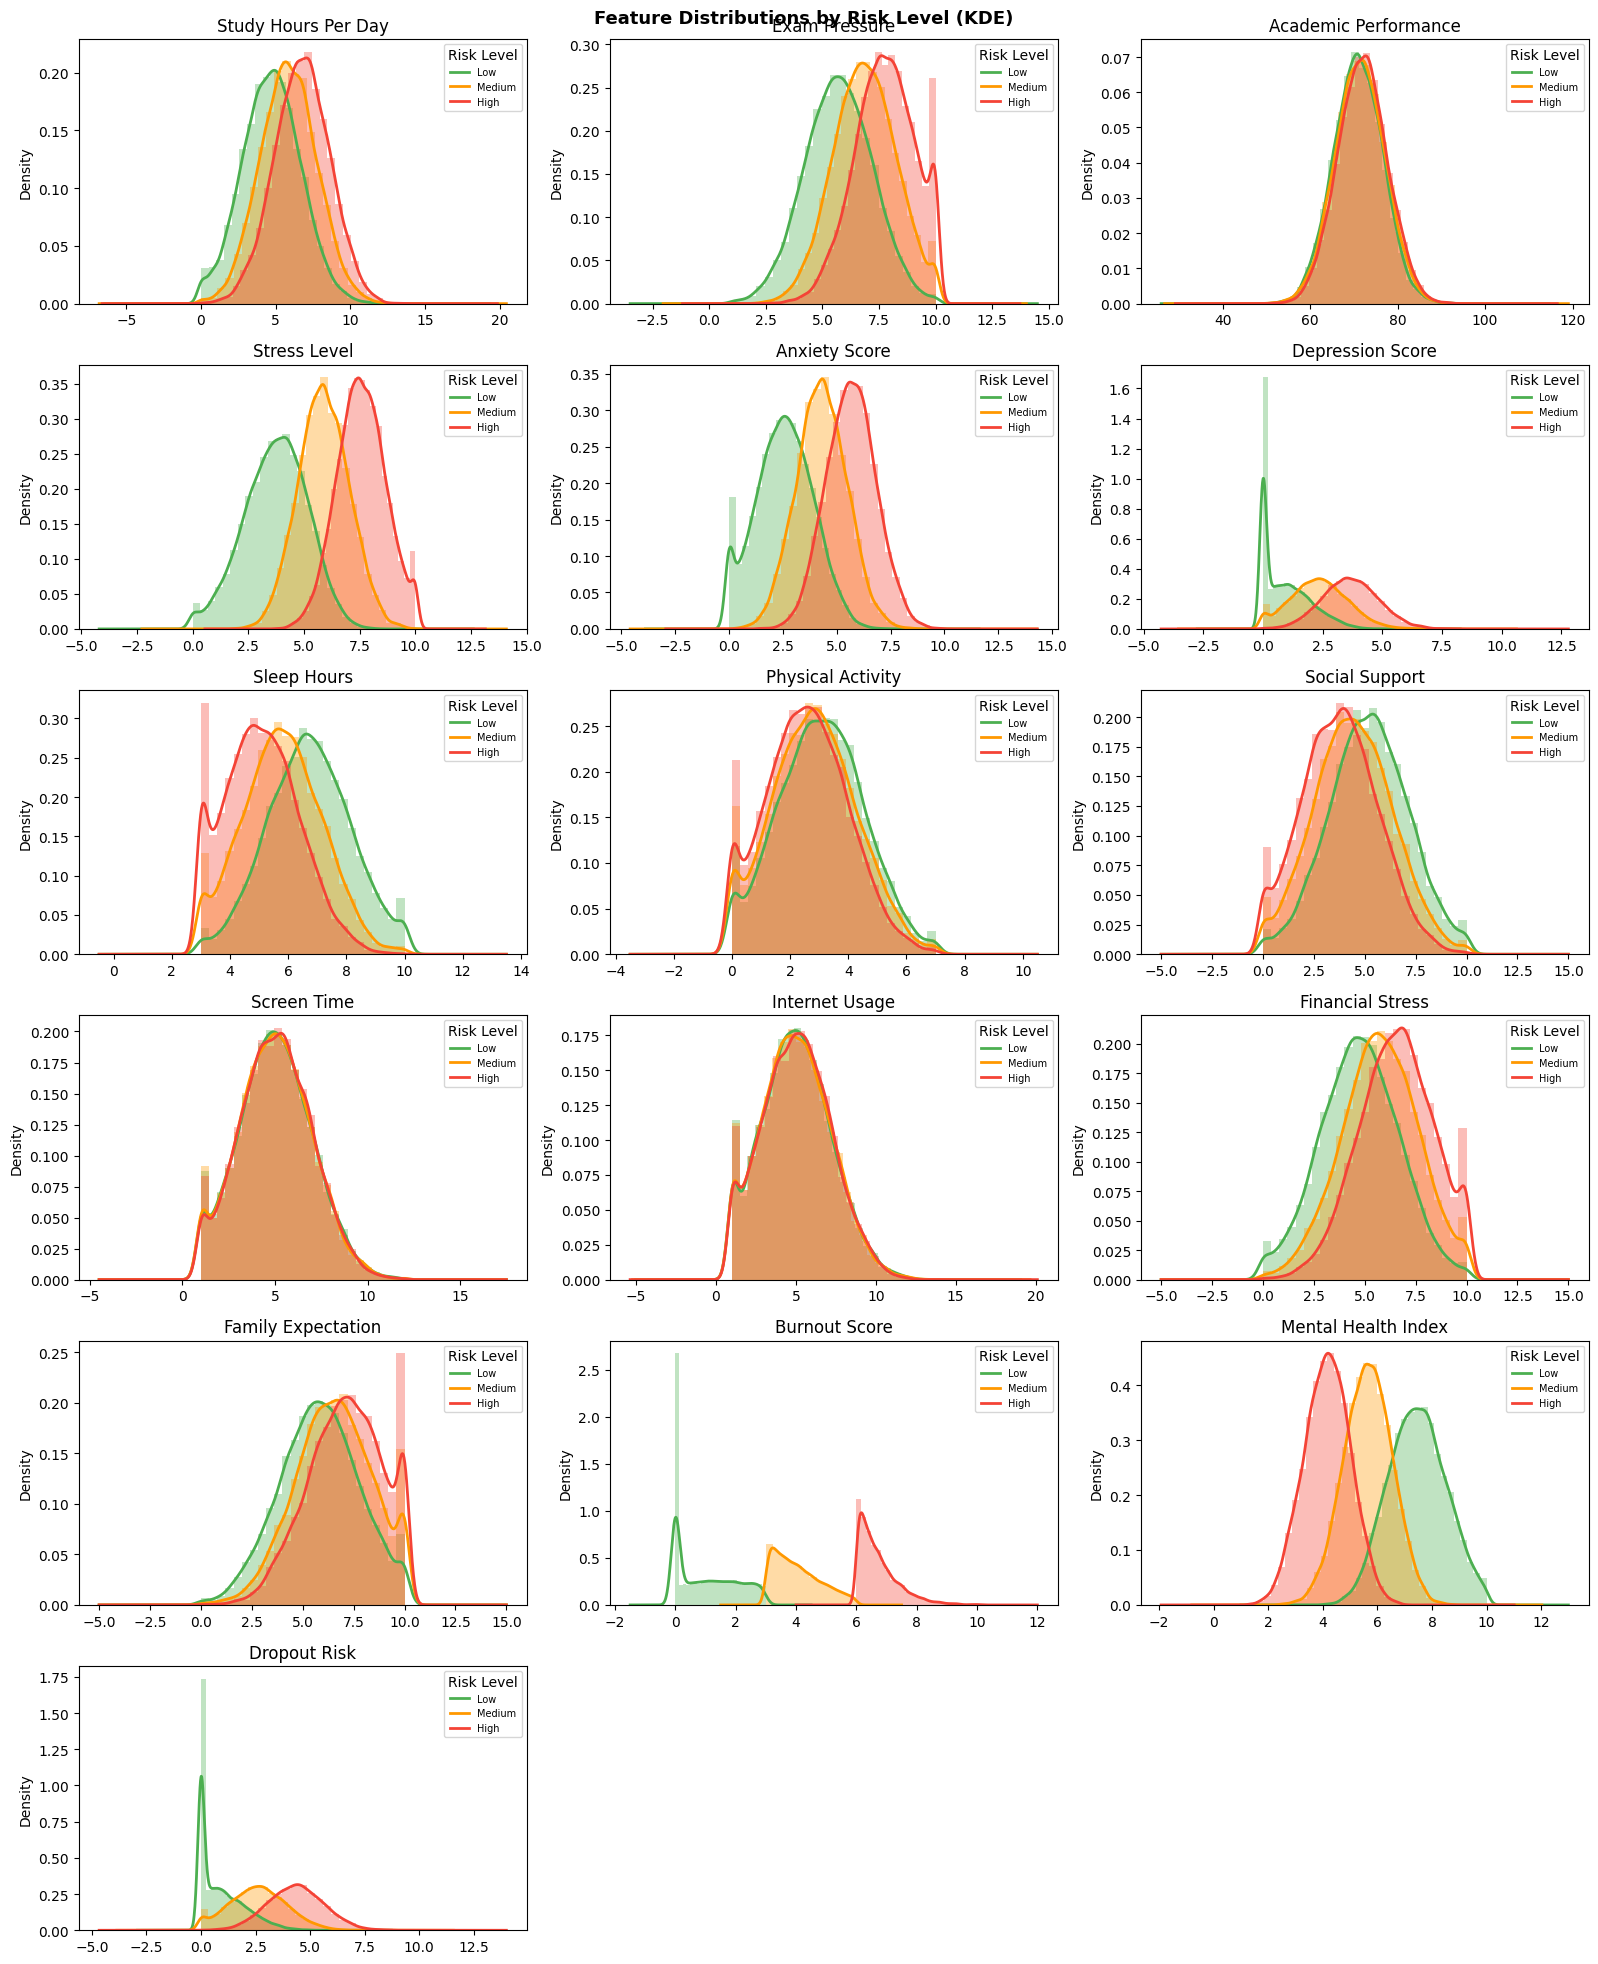

In [35]:
FEATURES_NUM = ['study_hours_per_day', 'exam_pressure', 'academic_performance',
                'stress_level', 'anxiety_score', 'depression_score',
                'sleep_hours', 'physical_activity', 'social_support',
                'screen_time', 'internet_usage', 'financial_stress',
                'family_expectation', 'burnout_score', 'mental_health_index',
                'dropout_risk']

fig, axes = plt.subplots(6, 3, figsize=(16, 20))
fig.suptitle("Feature Distributions by Risk Level (KDE)", fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(FEATURES_NUM):
    for lvl in ORDER:
        subset = df[df['risk_level'] == lvl][feat]
        axes[i].hist(subset, bins=25, alpha=0.35, color=PALETTE[lvl], density=True)
        subset.plot.kde(ax=axes[i], color=PALETTE[lvl], linewidth=2, label=lvl)
    axes[i].set_title(feat.replace('_', ' ').title())
    axes[i].set_ylabel("Density")
    axes[i].legend(title="Risk Level", fontsize=7)

# Hide sisa subplot
for j in range(len(FEATURES_NUM), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../data/processed/feature_distributions.png', bbox_inches='tight')
plt.show()

C:\Users\zahra\AppData\Local\Temp\ipykernel_11624\1765318927.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_class, labels=ORDER, patch_artist=True,
C:\Users\zahra\AppData\Local\Temp\ipykernel_11624\1765318927.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_class, labels=ORDER, patch_artist=True,
C:\Users\zahra\AppData\Local\Temp\ipykernel_11624\1765318927.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_class, labels=ORDER, patch_artist=True,
C:\Users\zahra\AppData\Local\Temp\ipykernel_11624\1765318927.py:7: MatplotlibDe

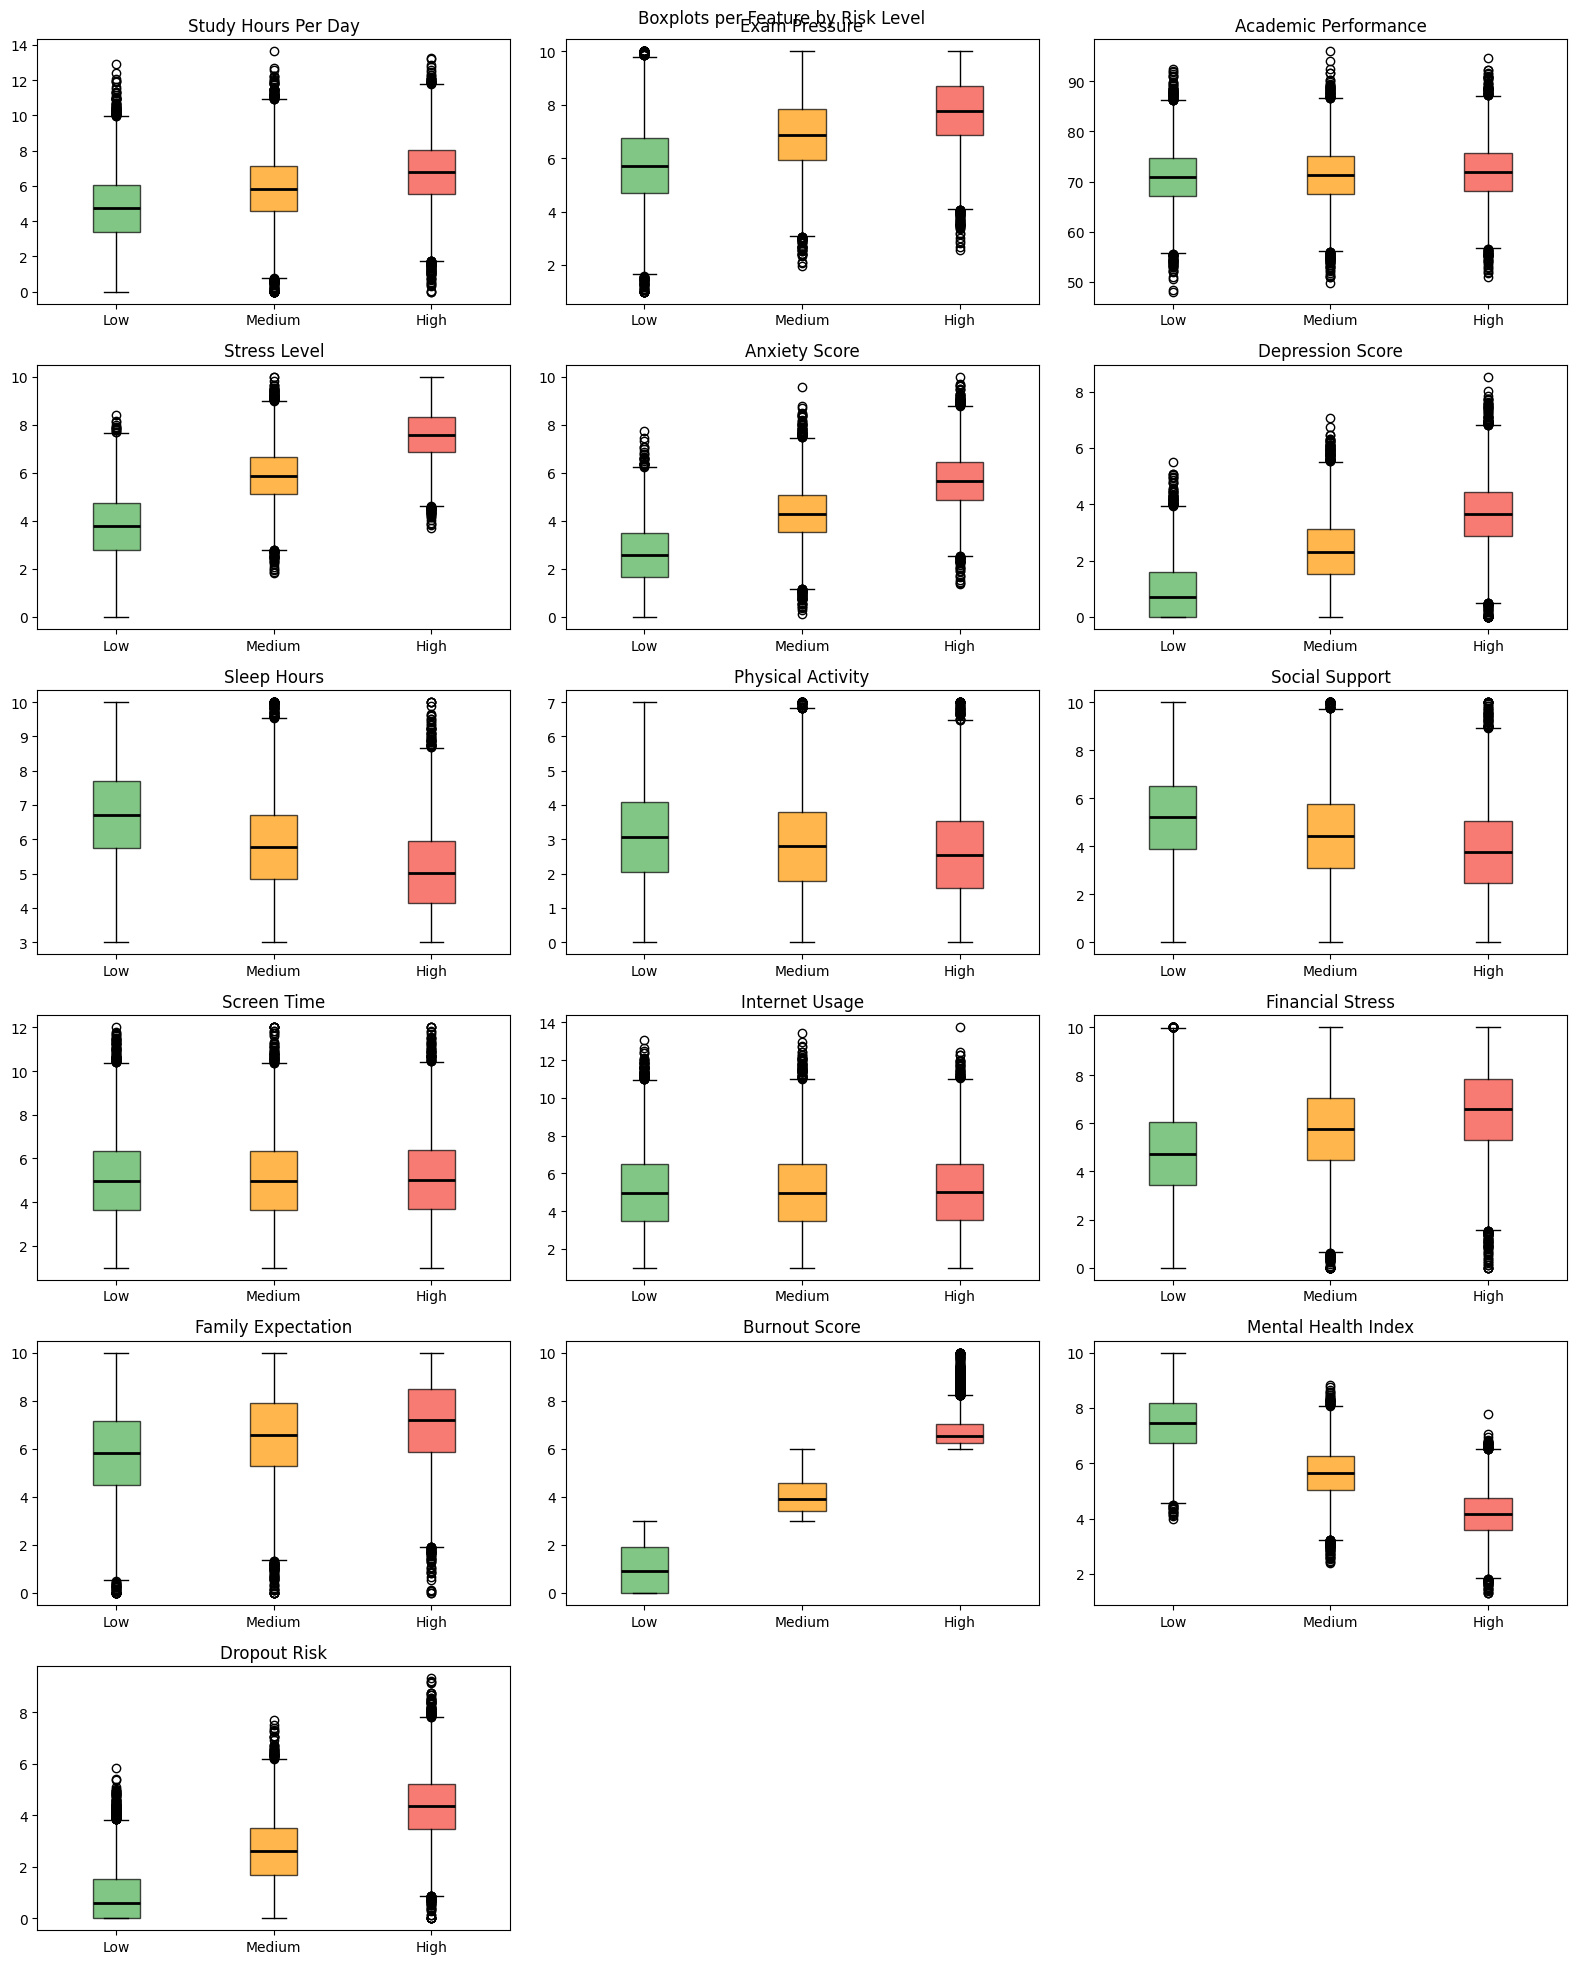

Outlier Count (IQR method):
  study_hours_per_day      :   279 outliers
  exam_pressure            :   164 outliers
  academic_performance     :   318 outliers
  stress_level             :   124 outliers
  anxiety_score            :    13 outliers
  depression_score         :    28 outliers
  sleep_hours              :     0 outliers
  physical_activity        :   152 outliers
  social_support           :   147 outliers
  screen_time              :   164 outliers
  internet_usage           :   168 outliers
  financial_stress         :   172 outliers
  family_expectation       :   158 outliers
  burnout_score            :     0 outliers
  mental_health_index      :     0 outliers
  dropout_risk             :    11 outliers


In [36]:
fig, axes = plt.subplots(6, 3, figsize=(16, 20))
fig.suptitle("Boxplots per Feature by Risk Level")
axes = axes.flatten()

for i, feat in enumerate(FEATURES_NUM):
    data_by_class = [df[df['risk_level'] == lvl][feat].values for lvl in ORDER]
    bp = axes[i].boxplot(data_by_class, labels=ORDER, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, lvl in zip(bp['boxes'], ORDER):
        patch.set_facecolor(PALETTE[lvl])
        patch.set_alpha(0.7)
    axes[i].set_title(feat.replace('_', ' ').title())

for j in range(len(FEATURES_NUM), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../data/processed/boxplots.png', bbox_inches='tight')
plt.show()

print("Outlier Count (IQR method):")
for feat in FEATURES_NUM:
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    print(f"  {feat:<25}: {n_out:>5} outliers")

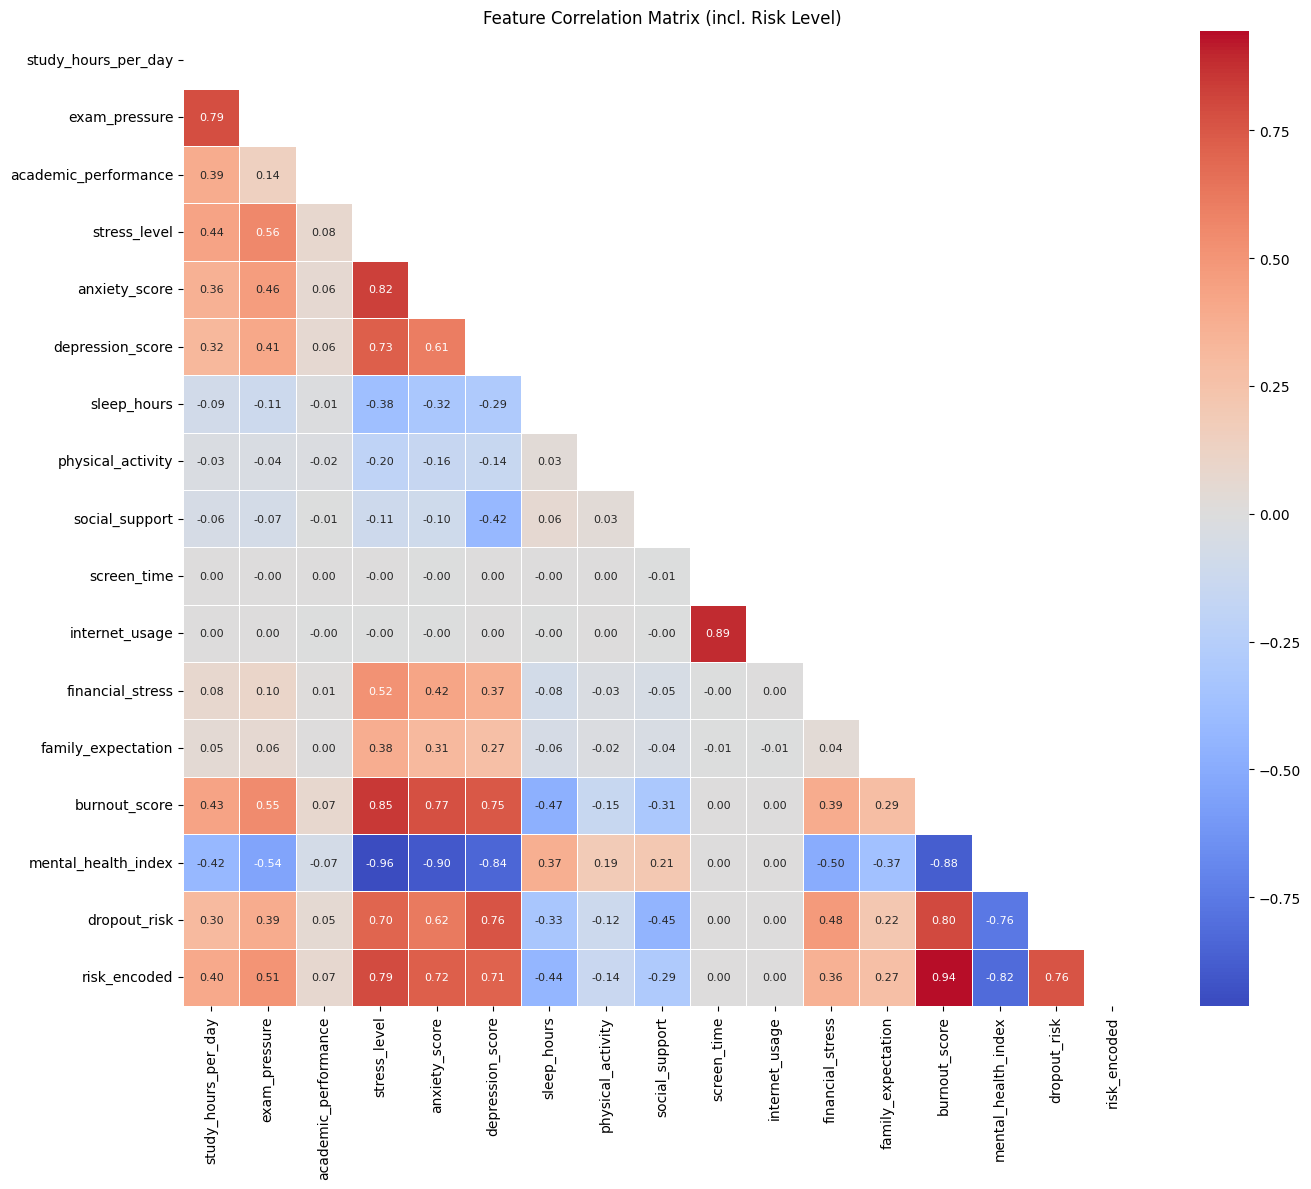


Korelasi dengan risk_encoded (sorted):
burnout_score           0.9435
stress_level            0.7881
dropout_risk            0.7604
anxiety_score           0.7205
depression_score        0.7071
exam_pressure           0.5104
study_hours_per_day     0.4024
financial_stress        0.3613
family_expectation      0.2662
academic_performance    0.0714
internet_usage          0.0028
screen_time             0.0021
physical_activity      -0.1378
social_support         -0.2880
sleep_hours            -0.4390
mental_health_index    -0.8199
Name: risk_encoded, dtype: float64


In [37]:
df_corr = df[FEATURES_NUM].copy()
df_corr['risk_encoded'] = df['risk_level'].map({'Low': 0, 'Medium': 1, 'High': 2})

fig, ax = plt.subplots(figsize=(14, 12))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title("Feature Correlation Matrix (incl. Risk Level)")
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("\nKorelasi dengan risk_encoded (sorted):")
print(corr['risk_encoded'].drop('risk_encoded').sort_values(ascending=False).round(4))

            study_hours_per_day  exam_pressure  academic_performance  stress_level  anxiety_score  depression_score  sleep_hours  physical_activity  social_support  screen_time  internet_usage  financial_stress  family_expectation  burnout_score  mental_health_index  dropout_risk
risk_level                                                                                                                                                                                                                                                                              
Low                       4.724          5.720                70.940         3.729          2.568             0.934        6.717              3.064           5.190        5.014           5.025             4.752               5.825          1.053                7.458         0.893
Medium                    5.861          6.874                71.359         5.893          4.301             2.334        5.789              2.822          

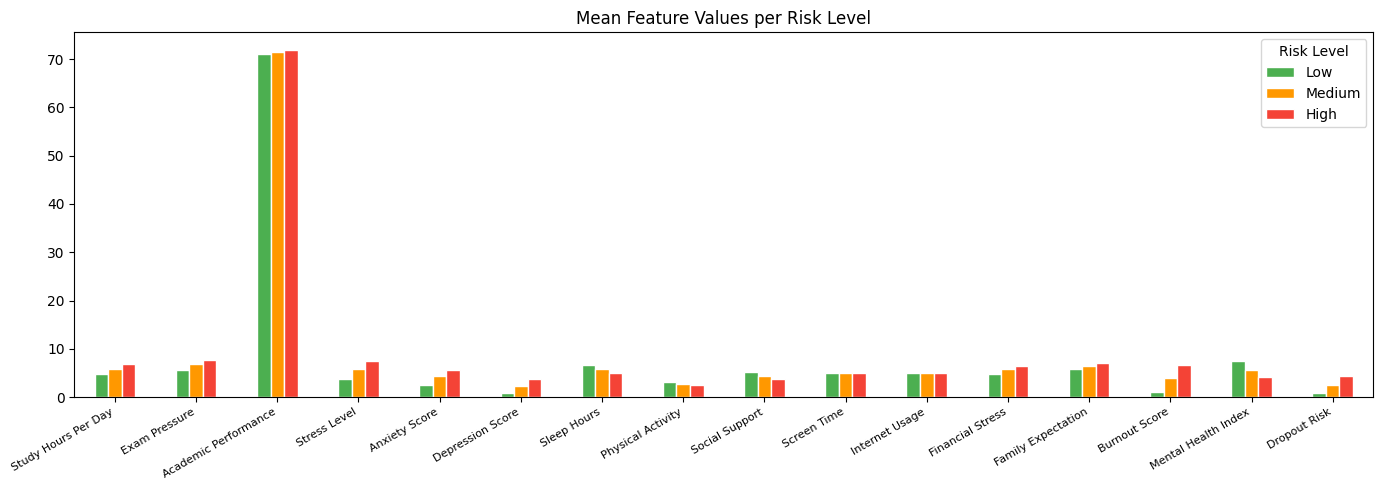

In [40]:
mean_table = df.groupby('risk_level')[FEATURES_NUM].mean().reindex(ORDER).round(3)
print(mean_table.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
mean_table.T.plot(kind='bar', ax=ax,
                  color=[PALETTE[l] for l in ORDER],
                  edgecolor='white')
ax.set_title("Mean Feature Values per Risk Level")
ax.set_xticklabels([f.replace('_', ' ').title() for f in FEATURES_NUM],
                   rotation=30, fontsize=8, ha='right')
ax.legend(title="Risk Level")
plt.tight_layout()
plt.savefig('../data/processed/mean_per_class.png', bbox_inches='tight')
plt.show()

EDA SUMMARY - KEY FINDINGS

Dataset
- Dataset    : 45,000 rows (sampled), 16 features + 1 target
- Source     : Student Mental Health Burnout (1M)           
- Quality    : No missing values, no duplicates            
- Target     : risk_level (Low / Medium / High)

Class Distributions
- Low    : 15,000  (33.3%)                                
- Medium : 15,000  (33.3%)                                
- High   : 15,000  (33.3%)                                
No class imbalance handling needed 

Top Correlated Features with risk_level
- burnout_score : +0.94
- mental_health_index : -0.82
-  stress_level : +0.79
